# Aprendizado por Reforço

---

**Professor:** Prof. Gabriel Lima  
**Aula:** 05  
**Exercício:** 5B  

---

### Objetivo :  
Implementar o algoritmo Q-learning para resolver o environment black jack da biblioteca gymnasium.

## Bibliotecas Utilizadas

Para a implementação dos algoritmos utilizaremos as seguintes bibliotecas: 

In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import random

## Definição do Ambiente

**Descrição:**
O ambiente `Blackjack-v1` simula o jogo de cartas Blackjack, onde o objetivo é vencer o dealer obtendo uma soma de cartas o mais próxima possível de 21, sem ultrapassá-lo. Todas as cartas são extraídas de um baralho infinito (com reposição).


**Espaço de Ações**

- **Tipo:** `Discrete(2)`
- **Ações:**
  - `0`: Parar (stick)
  - `1`: Pedir carta (hit)


**Espaço de Observação**

- **Tipo:** `Tuple(Discrete(32), Discrete(11), Discrete(2))`
- **Componentes:**
  1. Soma atual das cartas do jogador (4 a 21)
  2. Valor da carta visível do dealer (1 a 10, onde 1 representa o Ás)
  3. Indicador de Ás utilizável (`0`: Não, `1`: Sim)


**Recompensas**

- Vitória: `+1`
- Derrota: `-1`
- Empate: `0`
- Vitória com Blackjack natural (Ás + 10):
  - `+1.5` se `natural=True`
  - `+1` se `natural=False`


**Dinâmica do Jogo**

- O dealer começa com uma carta virada para cima e outra para baixo.
- O jogador recebe duas cartas visíveis.
- O jogador pode continuar pedindo cartas (`hit`) até decidir parar (`stick`) ou ultrapassar 21 (estourar).
- Após o jogador parar, o dealer revela sua carta oculta e continua comprando cartas até alcançar uma soma de 17 ou mais.
- Se o dealer estourar, o jogador vence.
- Se nenhum estourar, vence quem tiver a soma mais próxima de 21.


**Estado Inicial**

- **Soma do jogador:** 4 a 21
- **Carta visível do dealer:** 1 a 10
- **Ás utilizável:** `0` (Não) ou `1` (Sim)


**Parâmetros Opcionais**

- `natural` (bool): Se `True`, concede recompensa adicional para Blackjack natural.
- `sab` (bool): Se `True`, segue as regras descritas por Sutton e Barto, ignorando o parâmetro `natural`.


In [2]:
env = gym.make('Blackjack-v1',natural=False, sab=False)

In [3]:
print(env.observation_space)
print(env.action_space)

Tuple(Discrete(32), Discrete(11), Discrete(2))
Discrete(2)


## Definição do Agente

In [4]:
class Agent:
    def __init__(self, env, epsilon=1.0, alpha=0.01, gamma=0.95):
        self.env = env
        self.valid_actions = list(range(self.env.action_space.n))
        self.Q = dict()
        self.epsilon = epsilon
        self.alpha = alpha
        self.gamma = gamma


    def create_Q_if_new(self, state):
        if state not in self.Q:
            self.Q[state]= dict((action, 0.0) for action in self.valid_actions)

    def maxQ(self, state):
      self.create_Q_if_new(state)
      return max(self.Q[state].values())

    def action(self, state):

        self.create_Q_if_new(state)

        if random.random() > self.epsilon:
            maximumQ = self.maxQ(state)

            action = random.choice([k for k in self.Q[state].keys()
                                    if self.Q[state][k] == maximumQ])
        else:
            action = random.choice(self.valid_actions)
        return action

    def QLearn(self, state, action, reward, next_state):

        self.Q[state][action] +=\
         self.alpha * (reward + (self.gamma * self.maxQ(next_state))
                                                - self.Q[state][action])

### Instanciando as Classes

In [5]:
A = Agent(env=env, epsilon=0.9, alpha=0.3, gamma=0.975)

In [6]:
num_hands = 300
num_episodes = 200

### Aplicando o algortimo

**Inicialização:**
- Q(s, a) ← 0, ∀ s ∈ 𝒮, a ∈ 𝒜

**Repetir para cada episódio (até N episódios):**  
1. Inicializar s  
2. Repetir (para cada passo do episódio):  
   a. Escolher a a partir de s usando a política 𝜖-greedy baseada em Q  
   b. Executar ação a, observar recompensa r e próximo estado s'  
   c. Atualizar Q(s, a):  
      → Q(s, a) ← Q(s, a) + α × [r + γ × maxₐ' Q(s', a') − Q(s, a)]  
   d. s ← s'  
   e. Se s for terminal, sair do loop

**Saída:**  
- Função de ação-valor Q(s, a) ótima aproximada para a política ótima


In [7]:
state = env.reset()[0]
average_payouts = []

for episode in range(num_episodes):
  round = 1
  total_payout = 0

  while round <= num_hands:
      action = A.action(state)
      next_state, payout, done,info, _ = env.step(action)
      A.QLearn(state, action, payout, next_state)
      total_payout += payout
      state = next_state
      if done:
          state = env.reset()[0]
          round += 1
  average_payouts.append(total_payout)

  # Fazendo decay dos Hiperparâmetros
  A.epsilon -= 0.9/num_episodes
  A.alpha -= 0.25/num_episodes

## Visualização

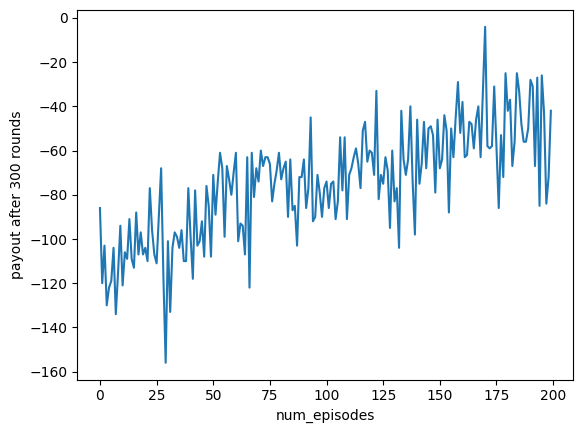

Blackjack with Q-Learning
Average payout after 300 rounds is -74.69


In [8]:
# Plot payout per 300 rounds for episode
plt.plot(average_payouts)
plt.xlabel('num_episodes')
plt.ylabel('payout after 300 rounds')
plt.show()

print("Blackjack with Q-Learning")
print ("Average payout after {} rounds is {}".\
       format(num_hands, sum(average_payouts)/(num_episodes)))